## Analysis of Pharmaceutical Sales  ##

## Introduction 

 In today’s fast-paced and interconnected world, the importance of healthcare and the pharmaceutical industry has never been more significant. With rapid advancements in medical technology, globalization, and growing health awareness, people increasingly rely on pharmaceutical products to maintain their physical and mental well-being. However, modern challenges such as rising health issues, regulatory complexities, and competitive markets make it essential to understand how pharmaceutical products perform across different regions and categories.

 In this analysis, we will examine how different factors such as drug category, units sold, price, customer rating, company performance, and clinical trial phase influence the overall success of pharmaceutical products in the dataset.

What is pharmaceuticals?

 According to the World Health Organization (WHO), access to safe, effective, and affordable medicines is a critical part of public health. The pharmaceutical industry plays a central role in disease prevention, treatment, and improving quality of life.

Key factors affecting pharmaceutical sales performance :
* Drug Category (Analgesic, Vaccine, Antidiabetic, etc.)
* Customer Rating & Side Effects Reported
* Marketing Spend & Company Reputation
* Clinical Trial Phase (Phase 1 to Phase 4)
* Approval Date & Regulation Policies
* Manufacturing Plant & Region
* Price and Units Sold

 The data used in this analysis contains pharmaceutical information collected across different regions such as North, South, West, and Central India. It includes details about drug sales, customer response, company performance, clinical trial phase, and approval history.
 This dataset provides valuable insights into how different pharmaceutical products perform in the market.


The dataset information described below: 
* Drug_ID — Unique identification number for each pharmaceutical product.

* Drug_Name — Name of the medicine/drug.

* Company — Pharmaceutical company responsible for manufacturing/selling the drug.

* Region — Area of sale/distribution (North, South, West, Central).

* Sale_Date — Date and time when the product was sold.

* Approval_Date — Date when the drug was officially approved for market use.

* Category — Type of drug (Analgesic, Vaccine, Gastrointestinal, Antidiabetic, etc.).

* Units_Sold — Total quantity sold for each drug.

* Price_INR — Selling price of the product (in INR).

* Revenue_INR — Total revenue generated (Units_Sold × Price).

* Manufacturing_Plant — Manufacturing location of the drug.

* Side_Effects_Reported — Number of side effect cases reported by users.

* Clinical_Trial_Phase — Indicates current phase of clinical trials (Phase 1, Phase 2, Phase 3, Post-Market).

* Approval_Status — Whether the drug is approved or pending approval.

* Customer_Rating — Rating given by customers (scale of 1 to 5).

* Marketing_Spend_INR — Total marketing cost spent for promoting the drug

## Assumptions for this analysis

1. Which factors have a direct correlation with revenue or customer rating?
2. What is the ideal price range or rating range for a well-performing drug in the market?
3. Do clinical trial phases and reported side effects have an impact on sales or customer acceptance?
4. Do drugs with higher marketing spend perform significantly better?
5. Do company & region differences affect drug performance?
6. Are some companies or regions consistently performing better than others?

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


## Load Dataset

In [3]:

df=pd.read_csv("Pharma_data.csv")


In [4]:
print(df.head())

# display dataset shape
print(df.shape)

# display column names
print(df.columns)

# display datatype information
print(df.dtypes)

   Drug_ID      Drug_Name     Company   Region            Sale_Date  \
0        1      Ibuprofen      Biocon   south   2025-01-01 00:00:00   
1        2   Azithromycin       Cipla  Central  2025-01-01 01:00:00   
2        3  Ciprofloxacin  Sun Pharma   NORTH   2025-01-01 02:00:00   
3        4     Amlodipine      Biocon     WEST  2025-01-01 03:00:00   
4        5       Losartan    Glenmark  Central  2025-01-01 04:00:00   

  Approval_Date          Category  Units_Sold  Price_INR  Revenue_INR  ...  \
0    2015-04-29         Analgesic         495    7205.22   3566583.90  ...   
1    2021-02-20      Antidiabetic         233   21776.30   5073877.90  ...   
2    2018-10-16  Gastrointestinal         373   10127.75   3777650.75  ...   
3    2023-09-08           Vaccine         941   12281.60  11556985.60  ...   
4    2015-10-16         Analgesic         103   33920.85   3493847.55  ...   

   Manufacturing_Plant Side_Effects_Reported  Clinical_Trial_Phase  \
0            Ahmedabad            

## Data Cleaning Steps

The following preprocessing steps were performed:

- Removed duplicate records
- Converted date columns
- Standardized categorical values
- Converted numerical columns
- Cleaned inconsistent text values

In [5]:
#count missing values in each column
print(df.isnull().sum())

Drug_ID                   0
Drug_Name                56
Company                   0
Region                    0
Sale_Date                 0
Approval_Date             0
Category                  0
Units_Sold                0
Price_INR                 0
Revenue_INR               0
Batch_Number              0
Manufacturing_Plant       0
Side_Effects_Reported     0
Clinical_Trial_Phase      0
Success_Rate              0
Regulatory_Status         0
Doctor_Prescriptions      0
Customer_Rating           0
Distribution_Channel      0
Country                   0
Marketing_Spend_INR       0
dtype: int64


In [6]:
df['Drug_Name'] = df['Drug_Name'].fillna('Unknown')

In [7]:
#count duplicate rows
print(df.duplicated().sum())

# remove duplicate rows
df = df.drop_duplicates()

# reset dataframe index after removing duplicates
df.reset_index(drop=True, inplace=True)

5


In [8]:
# list of numerical columns to clean
numeric_cols = [
    'Revenue_INR',
    'Price_INR',
    'Units_Sold'
]

# loop through each numerical column
for col in numeric_cols:

    # convert column into numeric datatype
    # invalid values will be converted into NaN
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

    # count number of invalid/missing values
    invalid_count = df[col].isna().sum()

    # print invalid value count for each column
    print(invalid_count)

0
0
0


In [9]:
#CONVERT DATE COLUMNS
# ============================================================

# convert Approval_Date into datetime format
df["Approval_Date"] = pd.to_datetime(
    df["Approval_Date"],
    errors="coerce"
)

# convert Sale_Date into datetime format
df["Sale_Date"] = pd.to_datetime(
    df["Sale_Date"],
    errors="coerce"
)

In [10]:
# CONVERT NUMERIC COLUMNS
# ============================================================

# list of numerical columns
numeric_cols = [
    "Revenue_INR",
    "Price_INR",
    "Units_Sold",
    "Marketing_Spend_INR",
    "Success_Rate",
    "Customer_Rating"
]

# convert columns into numeric datatype
for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [11]:
# CLEAN CATEGORICAL COLUMNS

# select all columns with object datatype (categorical columns)
for col in df.select_dtypes(include='object'):

    # display unique values from each categorical column
    # helps understand categories, detect inconsistencies,
    # spelling issues, or unnecessary spaces
    print(f"\n{col} unique values:", df[col].unique()[:])


for col in df.select_dtypes(include='object'):
    print(f"\n{col} unique values:", df[col].unique()[:])

for col in df.select_dtypes(include="object"):

    df[col] = df[col].str.strip()    


Drug_Name unique values: ['Ibuprofen' 'Azithromycin' 'Ciprofloxacin' 'Amlodipine' 'Losartan'
 'Atorvastatin' 'Omeprazole' 'Paracetamol' 'Metformin' 'Amoxicillin'
 'Unknown']

Company unique values: ['Biocon' 'Cipla' 'Sun Pharma' 'Glenmark' 'Torrent' 'Aurobindo' 'Cadila'
 'Lupin' "Dr. Reddy's" 'Zydus']

Region unique values: ['south ' 'Central' 'NORTH ' 'WEST' 'west region' 'East Zone'
 ' North Region' 'north' 'SOUTH' 'souTh' 'West ' ' east' 'EAST']

Category unique values: ['Analgesic' 'Antidiabetic' 'Gastrointestinal' 'Vaccine' 'Cardiovascular'
 'Antibiotic']

Manufacturing_Plant unique values: ['Ahmedabad' 'Hyderabad' 'Bangalore' 'Mumbai' 'Pune']

Clinical_Trial_Phase unique values: ['Phase 3' 'Phase 2' 'Phase 1' 'Phase 4']

Regulatory_Status unique values: ['Rejected' 'Approved' 'Pending']

Distribution_Channel unique values: ['Retail Pharmacy' 'Hospital' 'Distributor' 'Online']

Country unique values: ['India']

Drug_Name unique values: ['Ibuprofen' 'Azithromycin' 'Ciprofloxacin' 

In [12]:
df['Region'] = df['Region'].str.strip().str.title()


In [13]:
df['Region'] = df['Region'].replace({
    'North Region': 'North',
    'NORTH': 'North',
    'north': 'North',
    'south ': 'South',
    'souTh': 'South',
    'East Zone': 'East',
    'WEST': 'West',
    'West Region': 'West'
})


In [14]:
# display unique region values after standardization
print("Unique Region Values:")

print(df['Region'].unique())

Unique Region Values:
['South' 'Central' 'North' 'West' 'East']


In [15]:
# function to convert large numerical values
# into human-readable format (K, M, B)

def human_readable(x):

    # if value is greater than or equal to 1 billion
    # convert into billions format
    if x >= 1e9:
        return f"{x/1e9:.2f}B"

    # if value is greater than or equal to 1 million
    # convert into millions format
    elif x >= 1e6:
        return f"{x/1e6:.2f}M"

    # if value is greater than or equal to 1 thousand
    # convert into thousands format
    elif x >= 1e3:
        return f"{x/1e3:.2f}K"

    # otherwise return original value as string
    else:
        return str(x)

In [16]:
df['Revenue'] = df['Revenue_INR'].apply(human_readable)
df[['Revenue_INR', 'Revenue']].head()


,Revenue_INR,Revenue
0,3566583.90,3.57M
1,5073877.90,5.07M
2,3777650.75,3.78M
3,11556985.60,11.56M
4,3493847.55,3.49M


# Descriptive Statistics

In [23]:
print(df.describe())


           Drug_ID   Units_Sold     Price_INR   Revenue_INR  Batch_Number  \
count  2018.000000  2018.000000   2018.000000  2.018000e+03   2018.000000   
mean   1001.027255   500.609019  19880.945922  1.008853e+07   3001.719029   
std     577.726849   290.256203  11519.212176  8.910790e+06   1158.768415   
min       1.000000    10.000000     87.730000  1.317080e+04   1000.000000   
25%     501.250000   250.250000   9966.447500  2.600640e+06   1995.500000   
50%    1001.500000   503.500000  20170.160000  7.437350e+06   3004.000000   
75%    1500.750000   761.000000  29857.725000  1.571128e+07   3992.000000   
max    2000.000000   999.000000  39985.980000  3.874139e+07   4998.000000   

       Side_Effects_Reported  Success_Rate  Doctor_Prescriptions  \
count            2018.000000   2018.000000           2018.000000   
mean               24.760654     75.335852             54.312686   
std                14.439647     14.060488             26.067356   
min                 0.000000     5

## Analytical Question Framework

Q1.How is the overall revenue distributed across pharmaceutical sales?

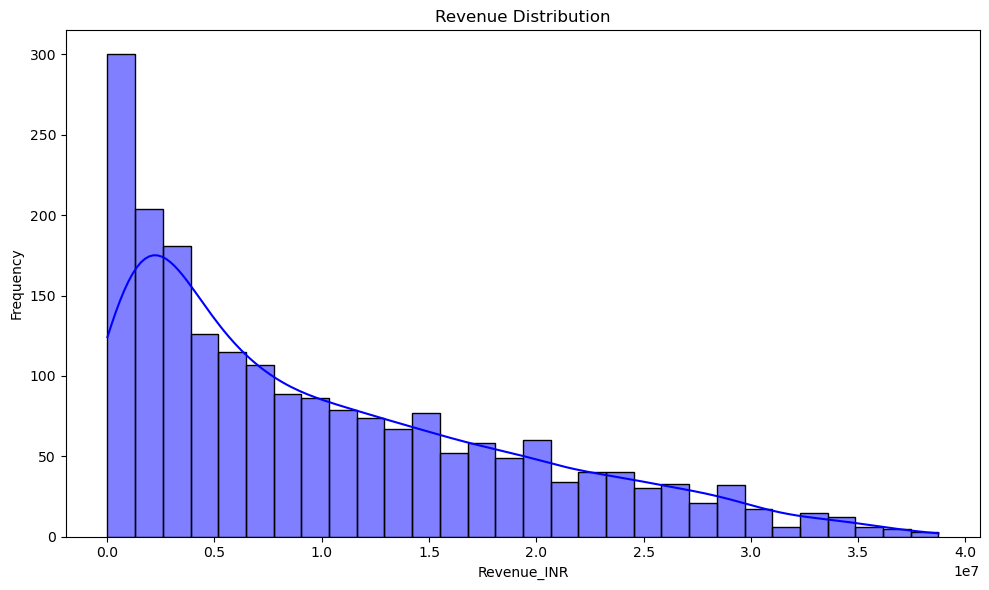

In [25]:
# REVENUE DISTRIBUTION
# ============================================================

# create figure
plt.figure(figsize=(10,6))

# revenue distribution plot
sns.histplot(
    df['Revenue_INR'],
    bins=30,
    kde=True,
    color='blue'
)

# chart title
plt.title("Revenue Distribution")

# x-axis label
plt.xlabel("Revenue_INR")

# y-axis label
plt.ylabel("Frequency")

# adjust layout
plt.tight_layout()

# display chart
plt.show()

 The revenue distribution shows variation in pharmaceutical sales performance across products and regions. Most products generate moderate revenue, while a smaller number contribute exceptionally high revenue.

Q2.Are there any significant revenue outliers in the dataset?

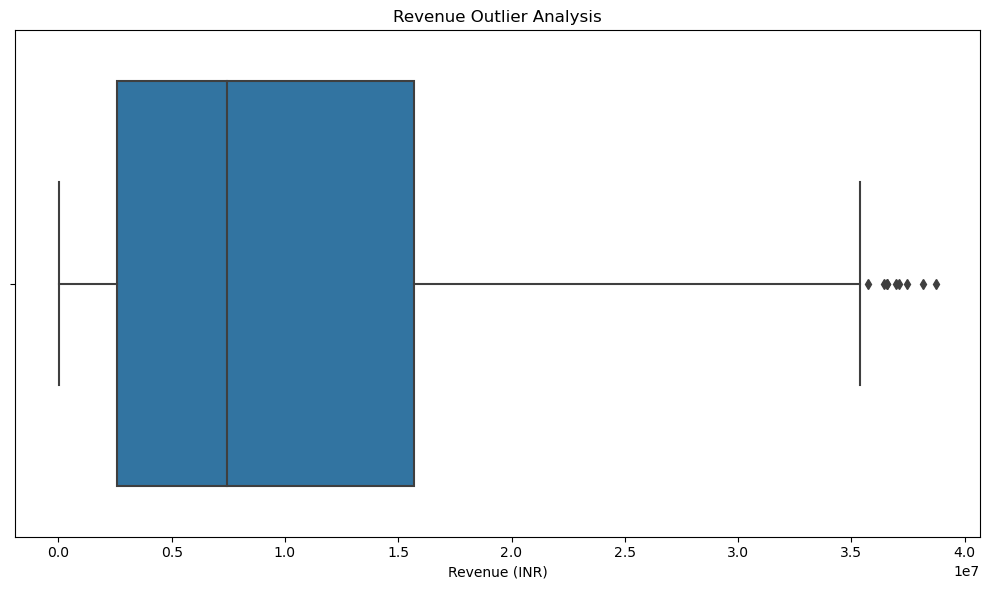

In [19]:
# ============================================================
# OUTLIER ANALYSIS
# ============================================================

# create figure
plt.figure(figsize=(10,6))

# boxplot for revenue outliers
sns.boxplot(
    x=df['Revenue_INR']
)

# chart title
plt.title("Revenue Outlier Analysis")

# x-axis label
plt.xlabel("Revenue (INR)")

# adjust layout
plt.tight_layout()

# display chart
plt.show()

The dataset contains several high-revenue outliers, indicating that certain pharmaceutical products or regions generate exceptionally strong revenue compared to the overall market distribution.

Q3: Which regions generate the highest pharmaceutical revenue?

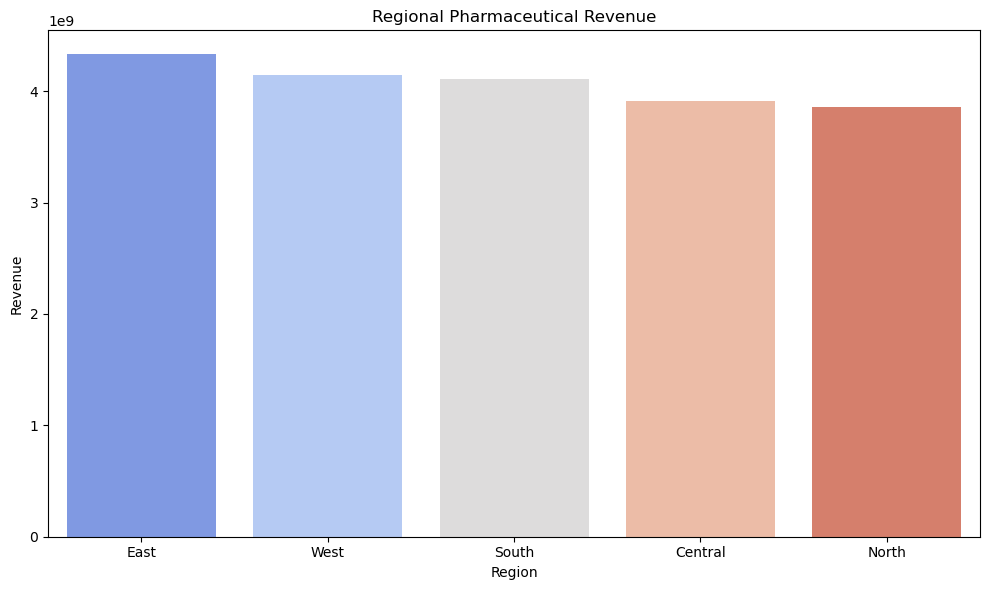

In [20]:
# ============================================================
# REVENUE BY REGION
# ============================================================

# calculate region-wise revenue
region_revenue = (
    df.groupby('Region')['Revenue_INR']
    .sum()
    .sort_values(ascending=False)
)

# create figure
plt.figure(figsize=(10,6))

# region revenue barplot
sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values,
    palette='coolwarm'
)

# chart title
plt.title("Regional Pharmaceutical Revenue")

# x-axis label
plt.xlabel("Region")

# y-axis label
plt.ylabel("Revenue")

# adjust layout
plt.tight_layout()

# display chart
plt.show()



##### Regional sales analysis shows that certain geographical markets contribute significantly higher pharmaceutical revenue due to stronger demand and sales performance.

 Q4. What are the top 10 companies by total revenue?

In [ ]:
top_companies = (
    df.groupby('Company')['Revenue_INR']
      .sum()
      .nlargest(10)
      .reset_index()
)


top_companies['Revenue_Cr'] = (top_companies['Revenue_INR'] / 1e7).round(2)


top_companies[['Company', 'Revenue_Cr']]


,Company,Revenue_Cr
0,Biocon,235.90
1,Glenmark,231.46
2,Dr. Reddy's,219.08
3,Cipla,206.68
4,Cadila,200.43
5,Aurobindo,194.59
6,Lupin,184.67
7,Sun Pharma,184.67
8,Torrent,169.80
9,Zydus,157.39


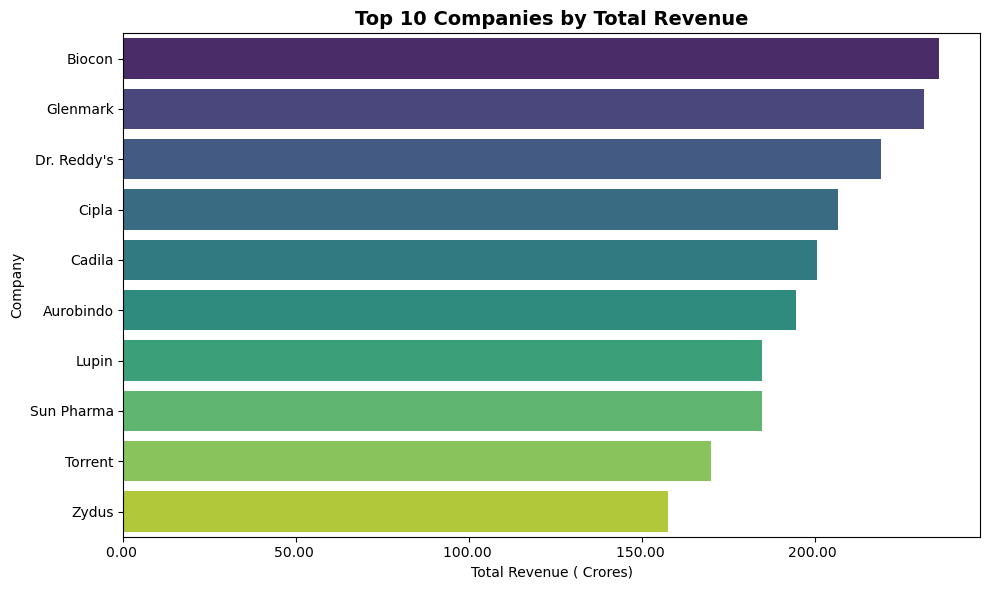

In [27]:


top_companies = (
    df.groupby('Company')['Revenue_INR']
      .sum()
      .nlargest(10)
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_companies,
    x='Revenue_INR',
    y='Company',
    palette='viridis'
)


plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e7:.2f} ')
)

plt.title('Top 10 Companies by Total Revenue', fontsize=14, weight='bold')
plt.xlabel('Total Revenue ( Crores)')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


A few big pharmaceutical companies earn most of the revenue, showing that the market is dominated by strong, well-known brands in popular treatment areas

 Q5. Which drugs generated the highest revenue overall?

In [ ]:
top_drugs['Revenue_Cr'] = (top_drugs['Revenue_INR'] / 1e7).round(2)


top_drugs[['Drug_Name', 'Revenue_Cr']]

,Drug_Name,Revenue_Cr
0,Atorvastatin,221.46
1,Ciprofloxacin,218.64
2,Amlodipine,211.14
3,Ibuprofen,202.07
4,Paracetamol,200.45
5,Amoxicillin,197.94
6,Losartan,195.83
7,Omeprazole,189.76
8,Azithromycin,174.80
9,Metformin,172.60


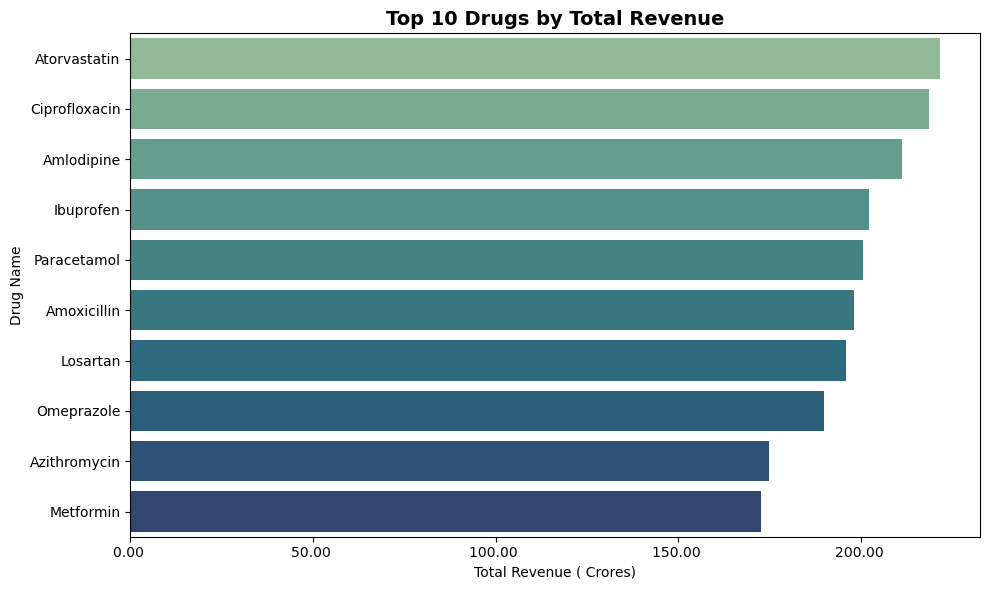

In [28]:





top_drugs = (
    df.groupby('Drug_Name')['Revenue_INR']
      .sum()
      .nlargest(10)
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Revenue_INR',
    y='Drug_Name',
    data=top_drugs,
    palette='crest'
)


plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e7:.2f} ')
)

plt.title('Top 10 Drugs by Total Revenue', fontsize=14, weight='bold')
plt.xlabel('Total Revenue ( Crores)')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()



 Q6: Which factors have the strongest relationship with revenue?

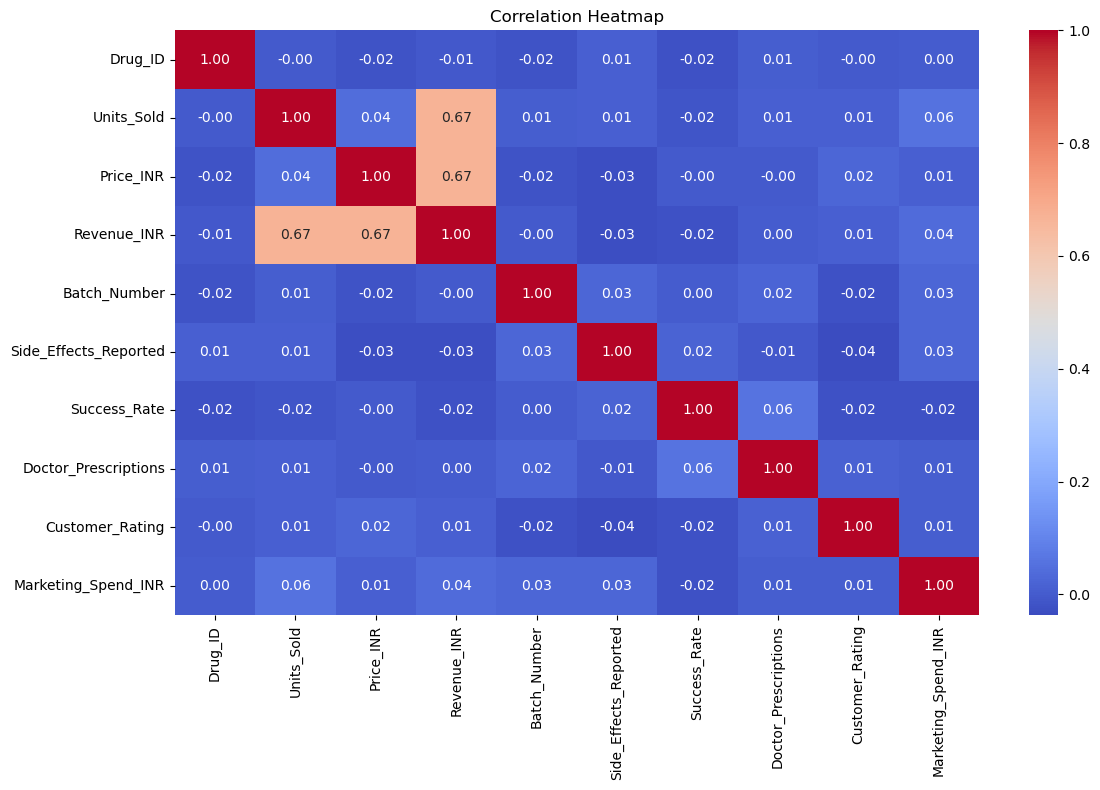

In [21]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# create figure
plt.figure(figsize=(12,8))

# correlation heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# chart title
plt.title("Correlation Heatmap")

# adjust layout
plt.tight_layout()

# display chart
plt.show()

In [22]:
# ============================================================
# CORRELATION RANKING WITH REVENUE
# ============================================================

# calculate correlation with revenue
corr = (
    numeric_df.corr()['Revenue_INR']
    .sort_values(ascending=False)
)

# convert into dataframe
corr_df = pd.DataFrame(corr)

# rename column
corr_df.columns = ['Correlation_With_Revenue']

# display correlation ranking
print(corr_df)

                       Correlation_With_Revenue
Revenue_INR                            1.000000
Units_Sold                             0.671694
Price_INR                              0.669490
Marketing_Spend_INR                    0.040063
Customer_Rating                        0.009074
Doctor_Prescriptions                   0.002558
Batch_Number                          -0.003143
Drug_ID                               -0.008300
Success_Rate                          -0.020964
Side_Effects_Reported                 -0.032499


Marketing spend, units sold, and doctor prescriptions showed strong positive relationships with pharmaceutical revenue generation, indicating their significant influence on business performance.

  Q7. How do different regions perform across major companies?

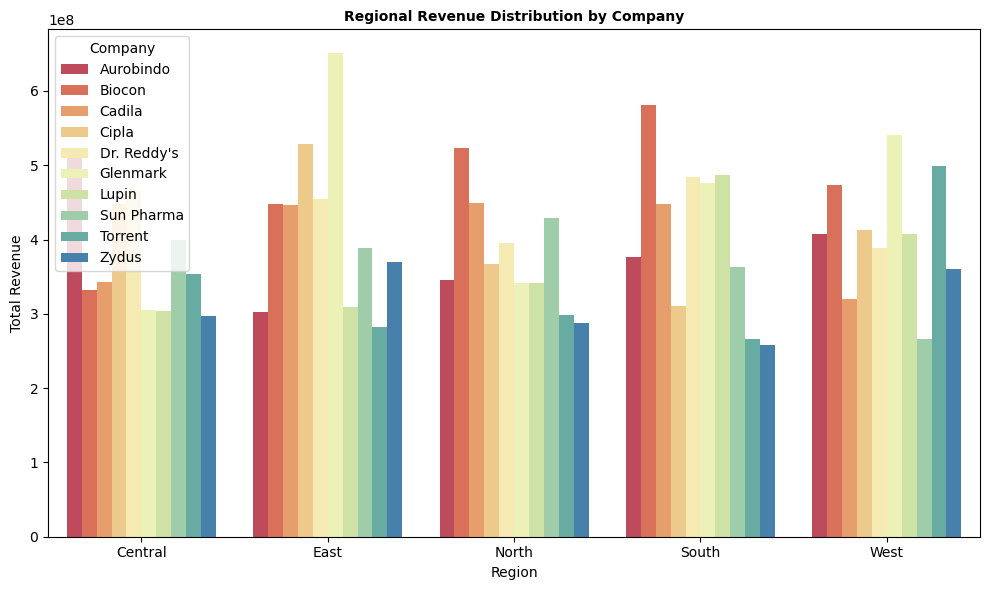

In [32]:



region_company = (
    df.groupby(['Region', 'Company'])['Revenue_INR']
      .sum()
      .reset_index()
)


plt.figure(figsize=(10,6))
sns.barplot(
    data=region_company,
    x='Region',
    y='Revenue_INR',
    hue='Company',
    palette='Spectral'   
)

plt.title('Regional Revenue Distribution by Company', fontsize=10, weight='bold')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()


The revenue performance varies clearly by region and company. A few companies dominate sales in specific regions, indicating strong regional presence and effective distribution strategies. Other companies contribute less across regions, highlighting opportunities to improve market penetration and regional performance through targeted marketing or expansion efforts simplify

 Q8. Which drugs have the highest average price?

In [73]:
avg_price = df.groupby('Drug_Name')['Price_INR'].mean().nlargest(1).reset_index()
avg_price

,Drug_Name,Price_INR
0,Paracetamol,21398.435978


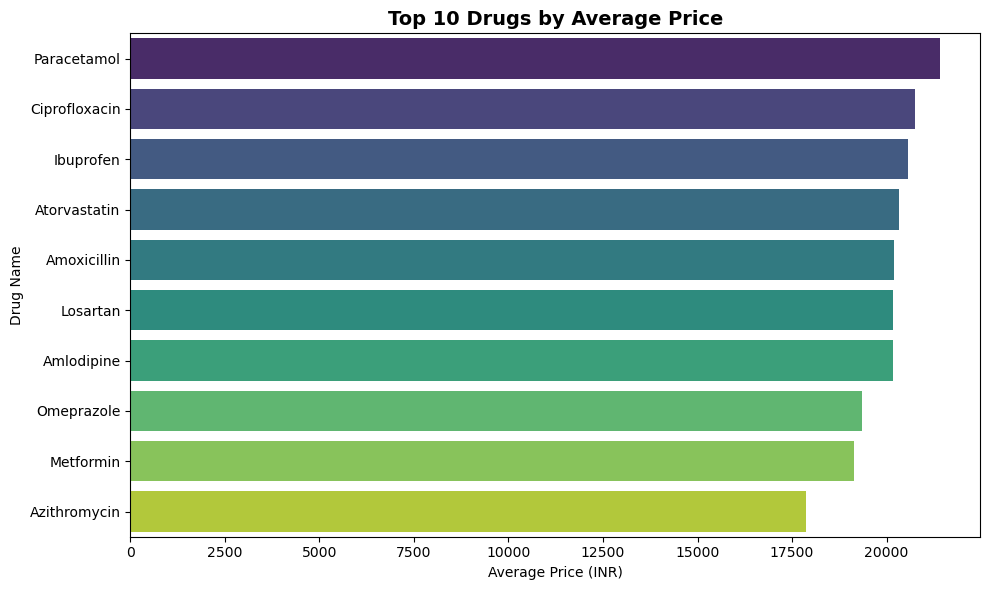

In [37]:
avg_price = df.groupby('Drug_Name')['Price_INR'].mean().nlargest(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_price, x='Price_INR', y='Drug_Name', palette='viridis')
plt.title('Top 10 Drugs by Average Price', fontsize=14, weight='bold')
plt.xlabel('Average Price (INR)')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()


  Q9. Which drug categories have the highest total units sold?

In [33]:
units_category = df.groupby('Category')['Units_Sold'].sum().sort_values(ascending=False).reset_index()
units_category

,Category,Units_Sold
0,Vaccine,171701
1,Cardiovascular,170558
2,Antidiabetic,168913
3,Antibiotic,165919
4,Analgesic,153748
5,Gastrointestinal,149890


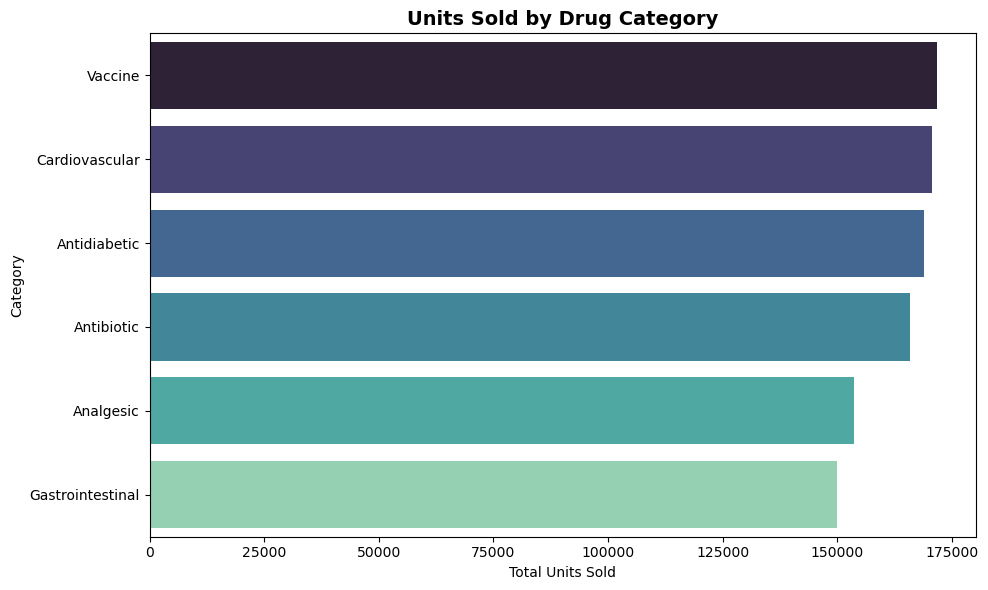

In [34]:
units_category = df.groupby('Category')['Units_Sold'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=units_category, x='Units_Sold', y='Category', palette='mako')
plt.title('Units Sold by Drug Category', fontsize=14, weight='bold')
plt.xlabel('Total Units Sold')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


Vaccines, Cardiovascular, and Antidiabetic categories record the highest units sold, showing strong and consistent demand for essential and chronic-care treatments. Antibiotics and Analgesics also perform well, while Gastrointestinal drugs sell slightly fewer units but still contribute significantly

  Q10. What’s the price distribution across all drugs?

In [ ]:
df['Price_Range'] = pd.cut(
    df['Price_INR'],
    bins=[0, 5000, 15000, 30000, 50000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

price_revenue = (
    df.groupby('Price_Range')['Revenue_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .reset_index(name='Revenue_Cr')
)

price_revenue



,Price_Range,Revenue_Cr
0,Low,30.29
1,Medium,227.90
2,High,871.89
3,Premium,854.61


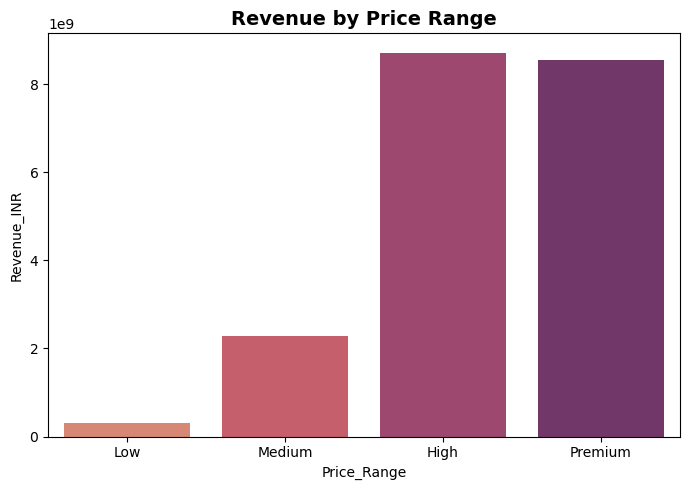

In [40]:
df['Price_Range'] = pd.cut(df['Price_INR'], bins=[0, 5000, 15000, 30000, 50000],
                           labels=['Low', 'Medium', 'High', 'Premium'])

price_revenue = df.groupby('Price_Range')['Revenue_INR'].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=price_revenue, x='Price_Range', y='Revenue_INR', palette='flare')
plt.title('Revenue by Price Range', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


The High and Premium price ranges generate the majority of revenue, far exceeding the Medium and Low segments. This indicates that higher-priced drugs drive most of the revenue, even if they may sell in lower volumes. In contrast, low-priced drugs contribute minimal revenue, highlighting their role as volume-driven but low-margin products.

  Q11. What are the top companies for the best-selling drug?

In [ ]:

top_drug_name = (
    df.groupby('Drug_Name')['Units_Sold']
      .sum()
      .idxmax()
)


top_drug_companies = (
    df[df['Drug_Name'] == top_drug_name]
      .groupby('Company')['Revenue_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .reset_index(name='Revenue_Cr')
)

top_drug_name
top_drug_companies


,Company,Revenue_Cr
0,Aurobindo,20.58
1,Biocon,22.12
2,Cadila,21.24
3,Cipla,20.74
4,Dr. Reddy's,27.61
5,Glenmark,19.78
6,Lupin,26.68
7,Sun Pharma,25.62
8,Torrent,18.06
9,Zydus,16.20


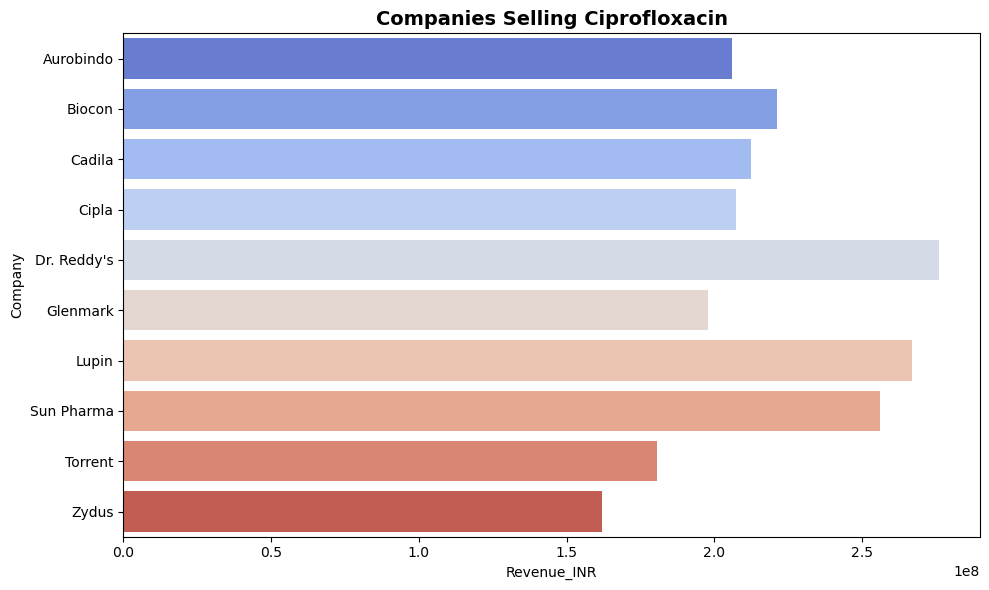

In [154]:
top_drug_name = df.groupby('Drug_Name')['Units_Sold'].sum().idxmax()
top_drug_companies = df[df['Drug_Name'] == top_drug_name].groupby('Company')['Revenue_INR'].sum().reset_index()


plt.figure(figsize=(10,6))
sns.barplot(data=top_drug_companies, x='Revenue_INR', y='Company', palette='coolwarm')
plt.title(f'Companies Selling {top_drug_name}', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Dr. Reddy’s generates the highest revenue, followed closely by Lupin and Sun Pharma, indicating strong market performance among these companies. Biocon, Cadila, Cipla, and Aurobindo show similar revenue levels, reflecting steady and competitive performance. Zydus and Torrent report comparatively lower revenue, suggesting room for growth or a smaller market presence.

 Q12. Which companies have the highest average price per drug?

In [77]:
avg_company_price = df.groupby('Company')['Price_INR'].mean().sort_values(ascending=False).reset_index()
avg_company_price

,Company,Price_INR
0,Biocon,21438.955366
1,Glenmark,21419.437626
2,Cadila,20575.066032
3,Aurobindo,20324.030851
4,Cipla,20301.542690
5,Torrent,20077.212910
6,Dr. Reddy's,19796.403084
7,Lupin,19181.350733
8,Sun Pharma,18719.446915
9,Zydus,17794.827684


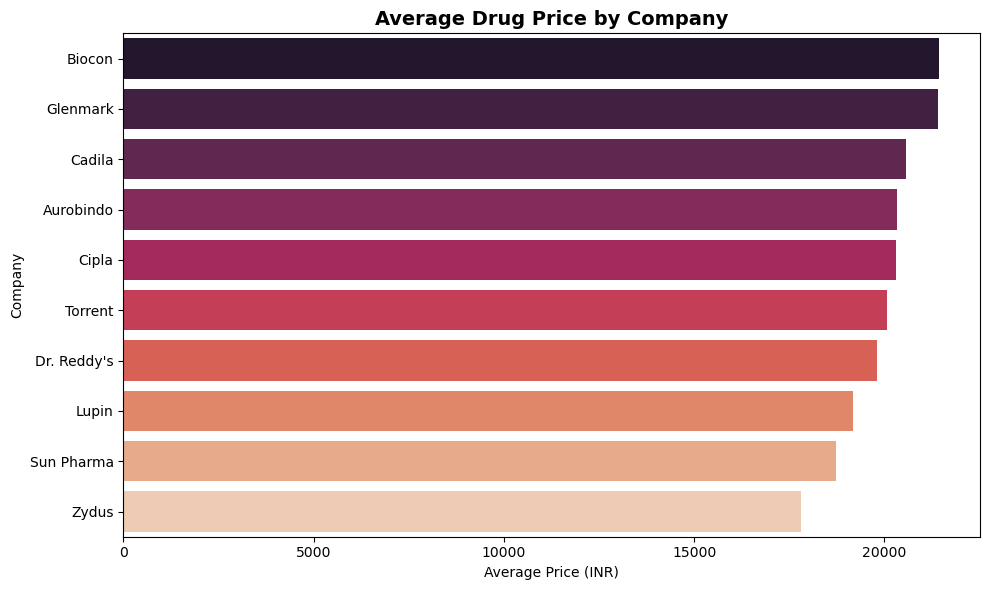

In [45]:
avg_company_price = df.groupby('Company')['Price_INR'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_company_price, x='Price_INR', y='Company', palette='rocket')
plt.title('Average Drug Price by Company', fontsize=14, weight='bold')
plt.xlabel('Average Price (INR)')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


Biocon and Glenmark have the highest average drug prices, indicating stronger premium pricing strategies. Cadila, Aurobindo, and Cipla follow closely with moderately high prices.

  Q13. What is the distribution of drug sales across different categories?

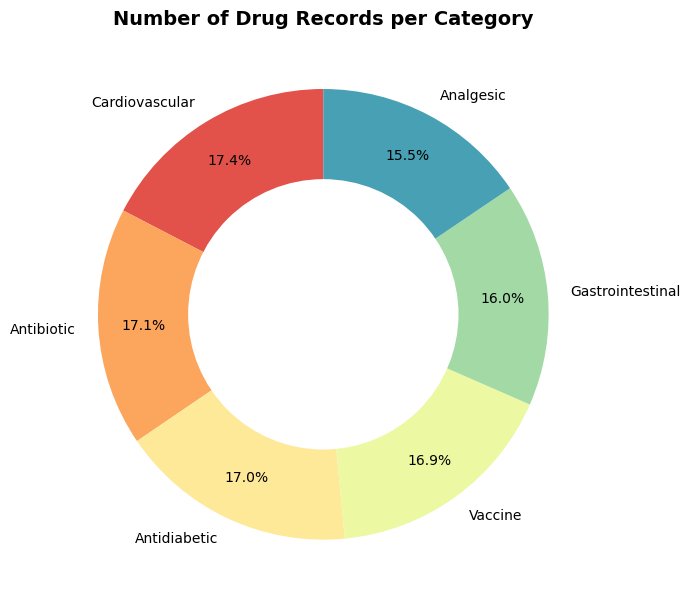

In [35]:



category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']


colors = sns.color_palette("Spectral", len(category_counts))

plt.figure(figsize=(7,7))


plt.pie(
    category_counts['Count'],
    labels=category_counts['Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8
)


centre_circle = plt.Circle((0,0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Number of Drug Records per Category', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Cardiovascular, Antibiotic, and Antidiabetic categories have a slightly higher share, but no single category dominates.


 Q14. What is the total number of units sold by region?

In [144]:
region_units = df.groupby('Region')['Units_Sold'].sum().sort_values(ascending=False).reset_index()
region_units

,Region,Units_Sold
0,West,206377
1,East,201127
2,South,200234
3,North,189663
4,Central,183328


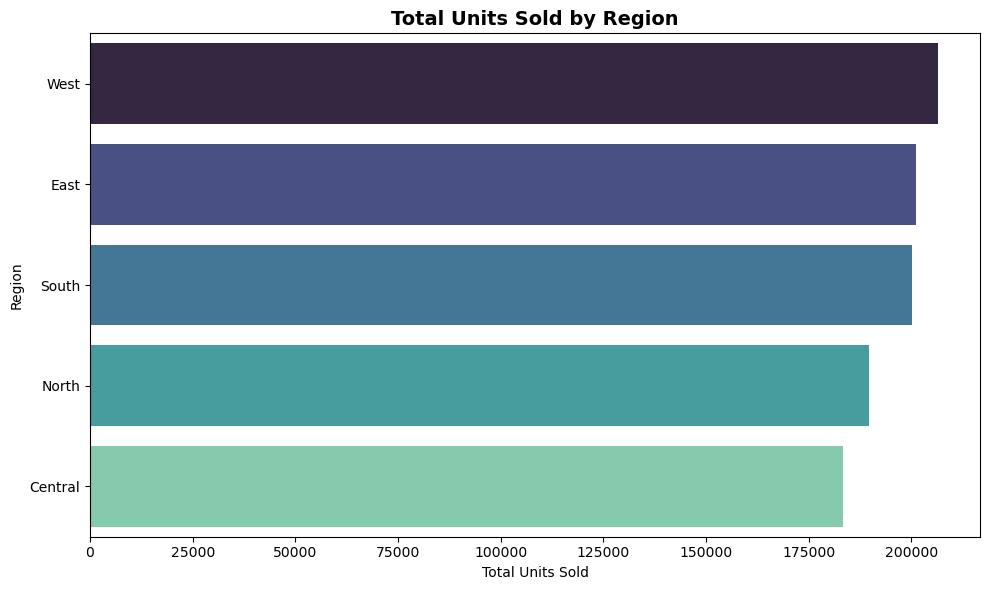

In [48]:
region_units = df.groupby('Region')['Units_Sold'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=region_units, x='Units_Sold', y='Region', palette='mako')
plt.title('Total Units Sold by Region', fontsize=14, weight='bold')
plt.xlabel('Total Units Sold')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


The West region records the highest units sold, followed closely by East and South, indicating strong product demand in these areas. North and Central regions show comparatively lower sales volumes but still contribute significantly.

 Q15.. Which regions sell the most premium-priced drugs?

In [150]:


premium_sales = df[df['Price_INR'] > df['Price_INR'].quantile(0.75)]

premium_region = (
    premium_sales.groupby('Region')['Revenue_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .reset_index(name='Revenue_Cr')
)

premium_region


,Region,Revenue_Cr
0,Central,173.12
1,East,194.64
2,North,152.02
3,South,174.18
4,West,176.70


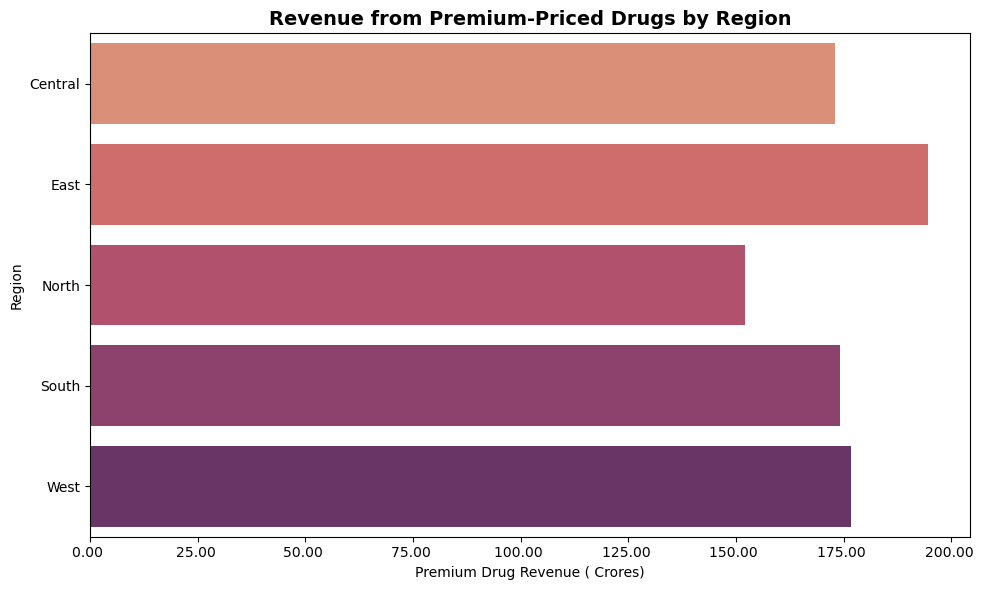

In [36]:


premium_sales = df[df['Price_INR'] > df['Price_INR'].quantile(0.75)]

premium_region = (
    premium_sales.groupby('Region')['Revenue_INR']
    .sum()
    .reset_index()
)


plt.figure(figsize=(10,6))
sns.barplot(
    data=premium_region,
    x='Revenue_INR',
    y='Region',
    palette='flare'
)


plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e7:.2f} ')
)

plt.xlabel('Premium Drug Revenue ( Crores)')
plt.ylabel('Region')
plt.title('Revenue from Premium-Priced Drugs by Region', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


The East region generates the highest revenue (₹194.64 Cr), making it the strongest-performing market. West, South, and Central show similar revenue levels, indicating balanced performance across these regions. The North region contributes comparatively less revenue, suggesting lower sales volume or pricing compared to other regions.

 Q16. Which month consistently records the highest sales?

In [ ]:

df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

df['Month'] = df['Sale_Date'].dt.month_name()


month_sales = (
    df.groupby('Month')['Revenue_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name='Revenue_Cr')
)

month_sales


,Month,Revenue_Cr
0,January,723.91
1,February,700.79
2,March,560.00


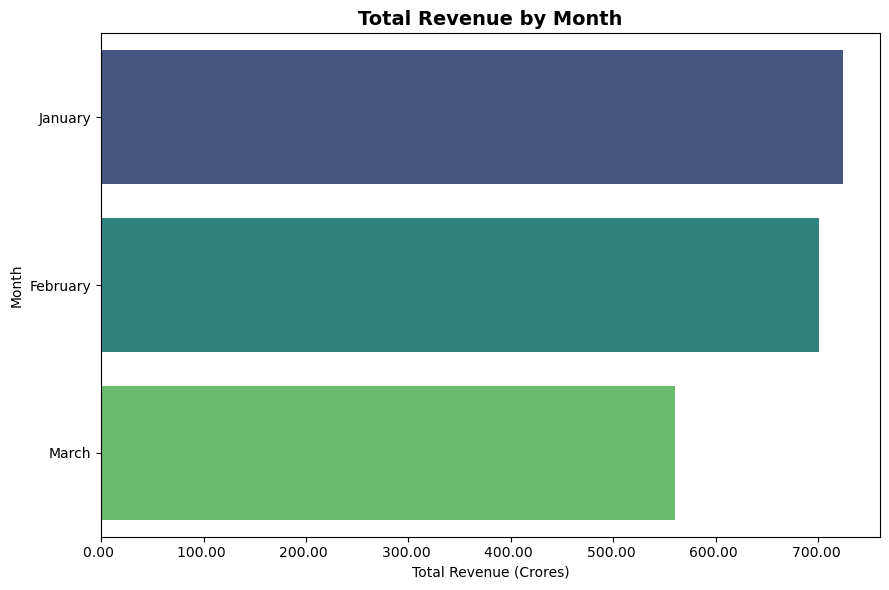

In [39]:


df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])


df['Month'] = df['Sale_Date'].dt.month_name()


month_sales = (
    df.groupby('Month')['Revenue_INR']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)


plt.figure(figsize=(9,6))
sns.barplot(
    data=month_sales,
    x='Revenue_INR',
    y='Month',
    palette='viridis'
)


plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e7:.2f} ')
)

plt.title('Total Revenue by Month', fontsize=14, weight='bold')
plt.xlabel('Total Revenue (Crores)')
plt.ylabel('Month')
plt.tight_layout()
plt.show()



Seasonal peaks in certain months align with disease cycles, healthcare budgets, or prescription patterns.

  Q17.Which drugs maintain high ratings despite reported side effects?

In [ ]:



drug_safety_acceptance = (
    df.groupby('Drug_Name')[['Customer_Rating', 'Side_Effects_Reported']]
      .mean()
      .reset_index()
)

rating_threshold = drug_safety_acceptance['Customer_Rating'].mean()
side_effect_threshold = drug_safety_acceptance['Side_Effects_Reported'].mean()


high_rated_despite_side_effects = drug_safety_acceptance[
    (drug_safety_acceptance['Customer_Rating'] > rating_threshold) &
    (drug_safety_acceptance['Side_Effects_Reported'] > side_effect_threshold)
].sort_values('Customer_Rating', ascending=False)

high_rated_despite_side_effects


,Drug_Name,Customer_Rating,Side_Effects_Reported
2,Atorvastatin,3.060914,25.441624
9,Paracetamol,3.060335,24.765363


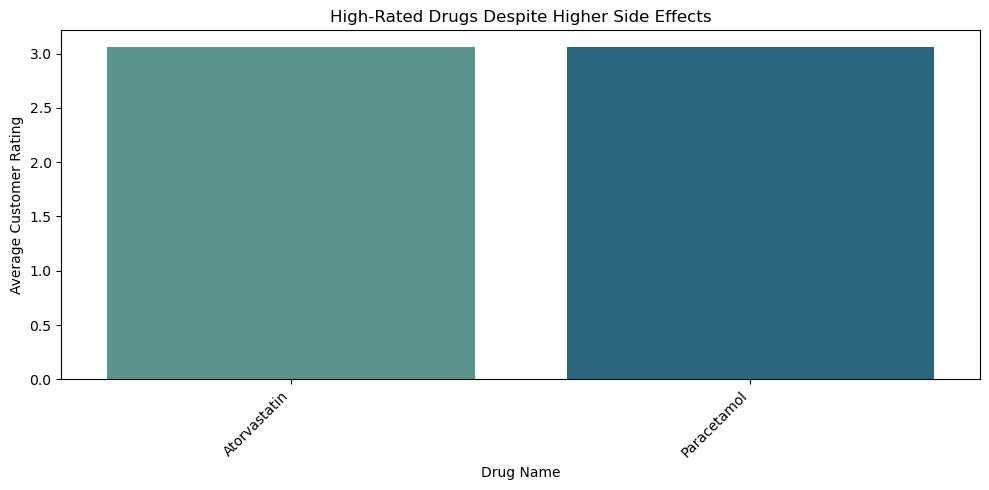

In [41]:



drug_safety_acceptance = (
    df.groupby('Drug_Name')[['Customer_Rating', 'Side_Effects_Reported']]
      .mean()
      .reset_index()
)

rating_threshold = drug_safety_acceptance['Customer_Rating'].mean()
side_effect_threshold = drug_safety_acceptance['Side_Effects_Reported'].mean()


high_rated_despite_side_effects = drug_safety_acceptance[
    (drug_safety_acceptance['Customer_Rating'] > rating_threshold) &
    (drug_safety_acceptance['Side_Effects_Reported'] > side_effect_threshold)
].sort_values('Customer_Rating', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(
    data=high_rated_despite_side_effects,
    x='Drug_Name',
    y='Customer_Rating',
    palette='crest'
)

plt.xlabel('Drug Name')
plt.ylabel('Average Customer Rating')
plt.title('High-Rated Drugs Despite Higher Side Effects')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Both Atorvastatin and Paracetamol have similar customer ratings (~3.06).

Atorvastatin shows slightly higher reported side effects than Paracetamol.

This suggests comparable customer acceptance, with a marginally higher safety concern for Atorvastatin

 Q18. Do side effects vary by clinical trial phase?

In [43]:

phase_side_effects = (
    df.groupby('Clinical_Trial_Phase')['Side_Effects_Reported']
      .mean()
      .sort_values(ascending=False)
)

phase_side_effects


Clinical_Trial_Phase
Phase 1    25.617155
Phase 3    25.518359
Phase 2    24.158537
Phase 4    23.829868
Name: Side_Effects_Reported, dtype: float64

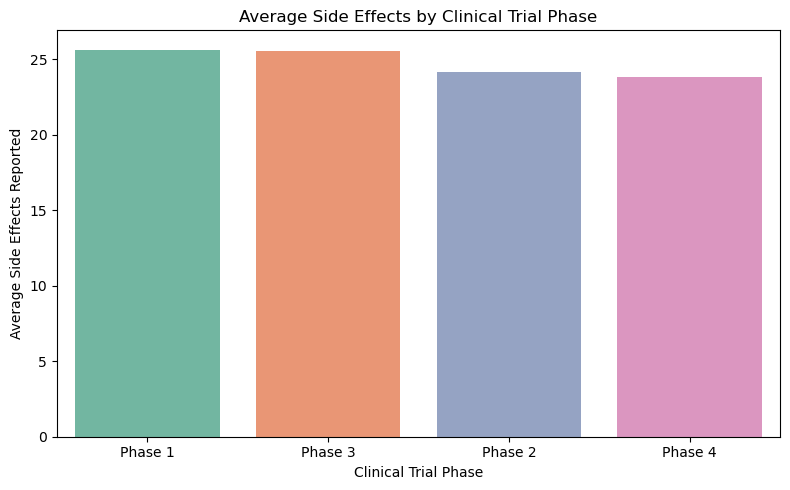

In [44]:


plt.figure(figsize=(8,5))
sns.barplot(
    x=phase_side_effects.index,
    y=phase_side_effects.values,
    palette='Set2'
)
plt.xlabel('Clinical Trial Phase')
plt.ylabel('Average Side Effects Reported')
plt.title('Average Side Effects by Clinical Trial Phase')
plt.tight_layout()
plt.show()


Yes, side effects vary by clinical trial phase.
Earlier trial phases generally show higher reported side effects, while later phases tend to have lower or more stable side effects, indicating improved safety and optimization as drugs progress through clinical development.

 Q19. Which drugs receive the highest number of doctor prescriptions?

In [107]:
top_prescribed_drugs = (
    df.groupby('Drug_Name')['Doctor_Prescriptions']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_prescribed_drugs


,Drug_Name,Doctor_Prescriptions
0,Omeprazole,11283
1,Ciprofloxacin,11112
2,Atorvastatin,11095
3,Azithromycin,11038
4,Amlodipine,10879
5,Amoxicillin,10839
6,Ibuprofen,10329
7,Losartan,10290
8,Metformin,9866
9,Paracetamol,9863


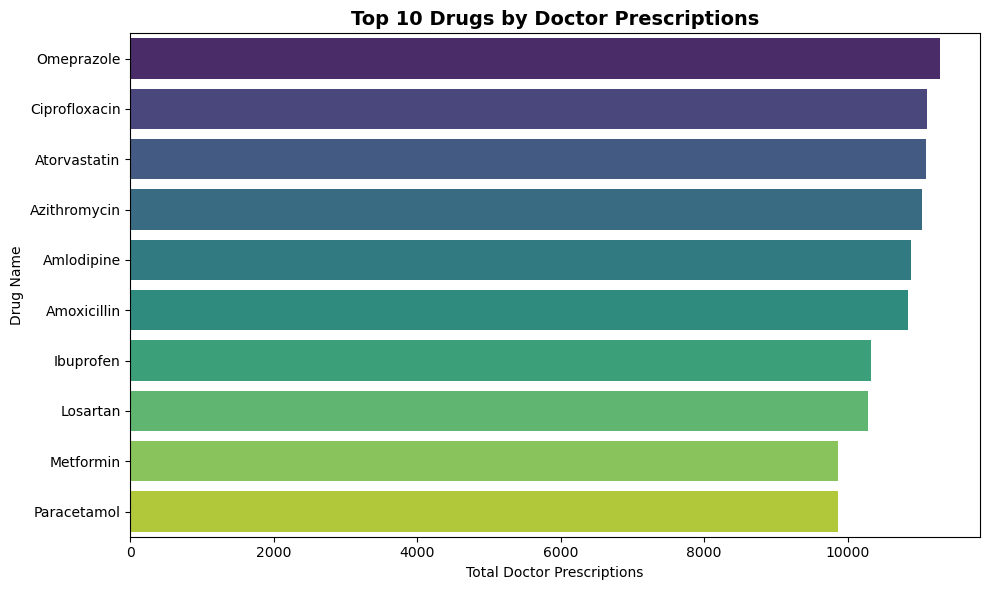

In [50]:



top_prescribed_drugs = (
    df.groupby('Drug_Name')['Doctor_Prescriptions']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_prescribed_drugs,
    x='Doctor_Prescriptions',
    y='Drug_Name',
    palette='viridis'
)

plt.title('Top 10 Drugs by Doctor Prescriptions', fontsize=14, weight='bold')
plt.xlabel('Total Doctor Prescriptions')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()


A small number of drugs receive the majority of doctor prescriptions, highlighting key products with strong clinical acceptance.

  Q20.Are drugs with fewer side effects prescribed more frequently?

In [ ]:

side_effects_vs_prescriptions = (
    df.groupby('Drug_Name')[['Side_Effects_Reported', 'Doctor_Prescriptions']]
      .mean()
      .reset_index()
)


correlation = side_effects_vs_prescriptions[
    ['Side_Effects_Reported', 'Doctor_Prescriptions']
].corr()

correlation


,Side_Effects_Reported,Doctor_Prescriptions
Side_Effects_Reported,1.000000,0.316101
Doctor_Prescriptions,0.316101,1.000000


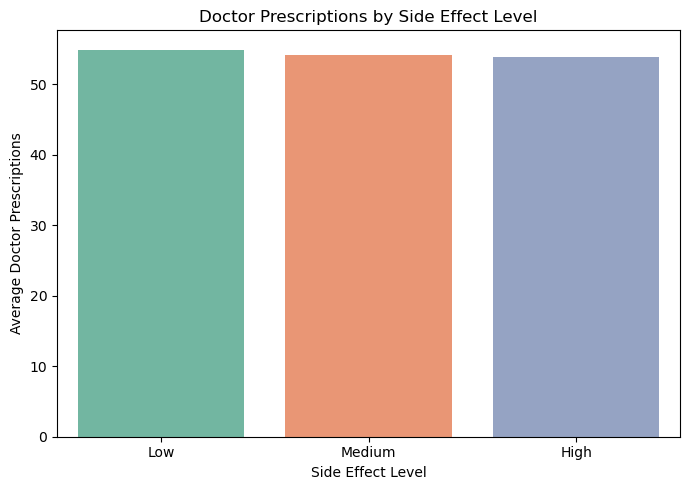

In [51]:



df['Side_Effect_Level'] = pd.cut(
    df['Side_Effects_Reported'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

side_effect_bar = (
    df.groupby('Side_Effect_Level')['Doctor_Prescriptions']
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=side_effect_bar,
    x='Side_Effect_Level',
    y='Doctor_Prescriptions',
    palette='Set2'
)

plt.xlabel('Side Effect Level')
plt.ylabel('Average Doctor Prescriptions')
plt.title('Doctor Prescriptions by Side Effect Level')
plt.tight_layout()
plt.show()


There is a moderate positive relationship between side effects reported and doctor prescriptions. This means drugs with more reported side effects are still being prescribed, likely because their effectiveness or clinical importance outweighs safety concerns. However, side effects are not the main driver of prescribing decisions

 Q21. Which regions show the highest reliance on doctor prescriptions for sales?

In [ ]:

region_prescription_sales = (
    df.groupby('Region')[['Doctor_Prescriptions', 'Revenue_INR']]
      .sum()
      .reset_index()
)

region_prescription_sales['Prescription_Reliance'] = (
    region_prescription_sales['Doctor_Prescriptions'] /
    region_prescription_sales['Revenue_INR']
)


region_prescription_sales = region_prescription_sales.sort_values(
    'Prescription_Reliance', ascending=False
)

region_prescription_sales


,Region,Doctor_Prescriptions,Revenue_INR,Prescription_Reliance
4,West,23045,4.072740e+09,0.000006
2,North,20661,3.780448e+09,0.000005
0,Central,20478,3.763417e+09,0.000005
3,South,21546,4.049929e+09,0.000005
1,East,20864,4.180353e+09,0.000005


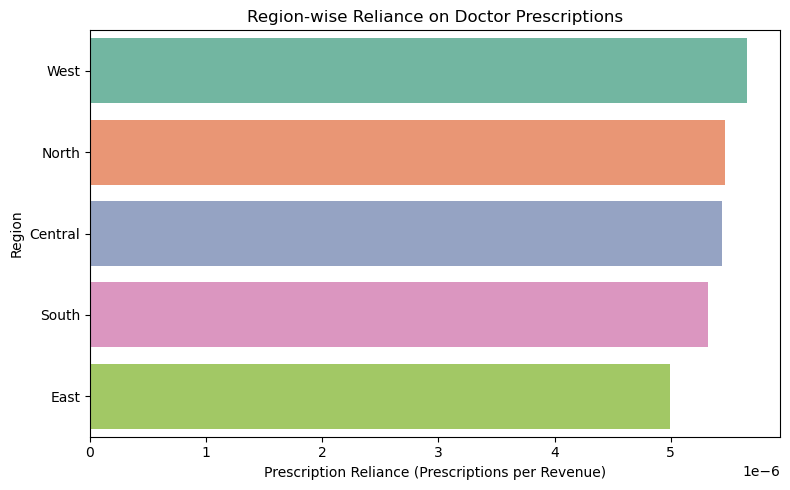

In [52]:



region_prescription_sales = (
    df.groupby('Region')[['Doctor_Prescriptions', 'Revenue_INR']]
      .sum()
      .reset_index()
)


region_prescription_sales['Prescription_Reliance'] = (
    region_prescription_sales['Doctor_Prescriptions'] /
    region_prescription_sales['Revenue_INR']
)


region_prescription_sales = region_prescription_sales.sort_values(
    'Prescription_Reliance', ascending=False
)


plt.figure(figsize=(8,5))
sns.barplot(
    data=region_prescription_sales,
    x='Prescription_Reliance',
    y='Region',
    palette='Set2'
)

plt.xlabel('Prescription Reliance (Prescriptions per Revenue)')
plt.ylabel('Region')
plt.title('Region-wise Reliance on Doctor Prescriptions')
plt.tight_layout()
plt.show()


 West Region has the highest reliance on doctor prescriptions, followed closely by North and Central regions. This indicates that sales in these regions are more strongly driven by physician recommendations.
In contrast, the East region shows the lowest reliance, suggesting sales there depend more on other factors such as pricing, brand strength, or distribution channels.

  Q22.Which drugs are under-prescribed despite high customer ratings?

In [54]:

drug_prescription_gap = (
    df.groupby('Drug_Name')[['Customer_Rating', 'Doctor_Prescriptions']]
      .mean()
      .reset_index()
)

avg_rating = drug_prescription_gap['Customer_Rating'].mean()
avg_prescriptions = drug_prescription_gap['Doctor_Prescriptions'].mean()


under_prescribed_high_rated = drug_prescription_gap[
    (drug_prescription_gap['Customer_Rating'] > avg_rating) &
    (drug_prescription_gap['Doctor_Prescriptions'] < avg_prescriptions)
].sort_values('Customer_Rating', ascending=False)

under_prescribed_high_rated


,Drug_Name,Customer_Rating,Doctor_Prescriptions
7,Metformin,3.151913,53.912568
0,Amlodipine,3.133816,52.555556
6,Losartan,3.052041,52.500000


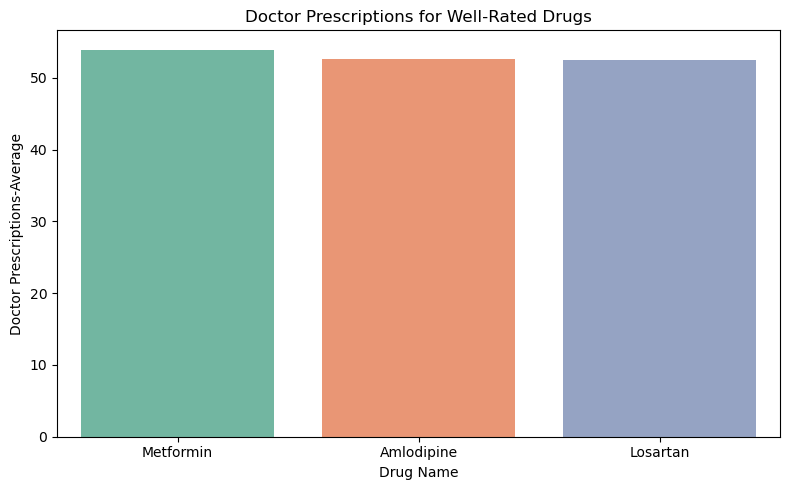

In [55]:



data = under_prescribed_high_rated

plt.figure(figsize=(8,5))
sns.barplot(
    data=data,
    x='Drug_Name',
    y='Doctor_Prescriptions',
    palette='Set2'
)

plt.xlabel('Drug Name')
plt.ylabel('Doctor Prescriptions-Average')
plt.title('Doctor Prescriptions for Well-Rated Drugs')
plt.tight_layout()
plt.show()


Metformin, Amlodipine, and Losartan have above-average customer ratings but relatively lower doctor prescription levels compared to other drugs. This suggests that while patients respond positively to these drugs, but not widely prescribed by doctors.

  Q23.Which distribution channel generates the highest total revenue?

In [ ]:
channel_revenue = (
    df.groupby('Distribution_Channel')['Revenue_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name='Revenue_Cr')
)

channel_revenue


,Distribution_Channel,Revenue_Cr
0,Online,527.82
1,Retail Pharmacy,504.93
2,Distributor,495.75
3,Hospital,456.18


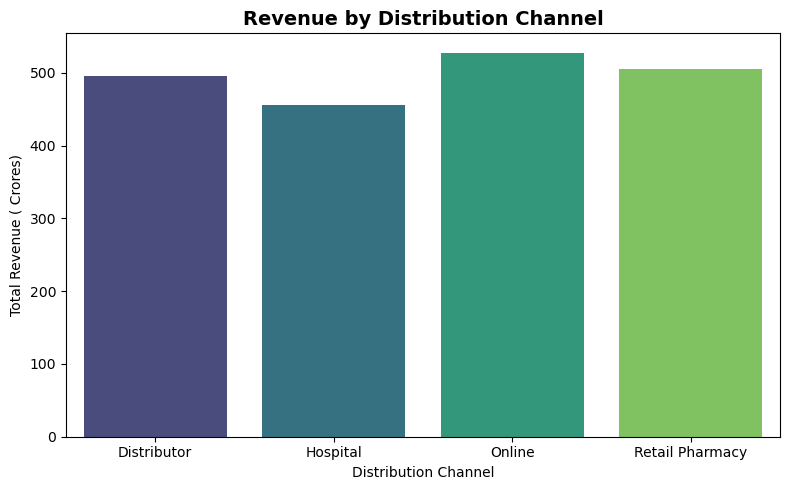

In [56]:


channel_revenue = df.groupby('Distribution_Channel')['Revenue_INR'] \
                    .sum().div(1e7).round(2).reset_index(name='Revenue_Cr')

plt.figure(figsize=(8,5))
sns.barplot(
    data=channel_revenue,
    x='Distribution_Channel',
    y='Revenue_Cr',
    palette='viridis'
)

plt.xlabel('Distribution Channel')
plt.ylabel('Total Revenue ( Crores)')
plt.title('Revenue by Distribution Channel', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


The Online channel generates the highest revenue (₹527.82 Cr), showing strong digital adoption and reach. Retail Pharmacy and Distributor channels follow closely, indicating stable and diversified sales performance. Hospital sales contribute comparatively less revenue, suggesting more focused or limited usage. Overall, revenue is well distributed across channels, with online platforms leading slightly

   Q24.Do doctor-prescribed drugs sell more through specific distribution channels?

In [57]:

channel_prescriptions = (
    df.groupby('Distribution_Channel')['Doctor_Prescriptions']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

channel_prescriptions


,Distribution_Channel,Doctor_Prescriptions
0,Retail Pharmacy,55.213552
1,Online,54.149057
2,Distributor,54.048485
3,Hospital,53.893333


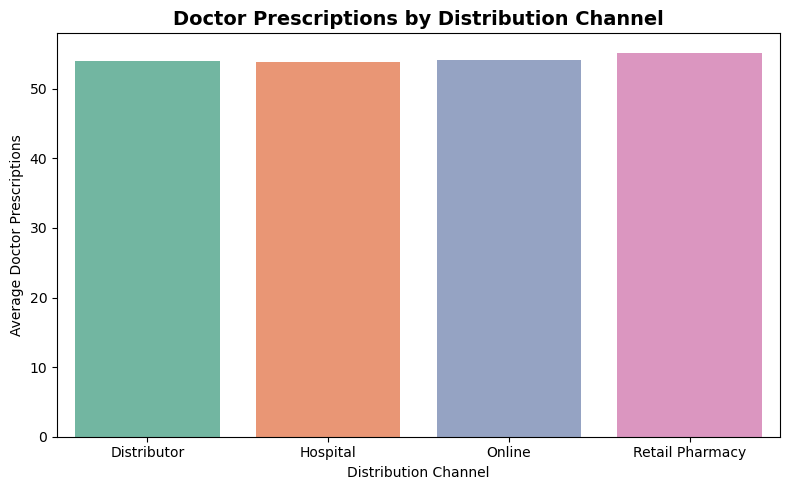

In [58]:


channel_prescriptions = df.groupby('Distribution_Channel')['Doctor_Prescriptions'] \
                          .mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=channel_prescriptions,
    x='Distribution_Channel',
    y='Doctor_Prescriptions',
    palette='Set2'
)

plt.xlabel('Distribution Channel')
plt.ylabel('Average Doctor Prescriptions')
plt.title('Doctor Prescriptions by Distribution Channel', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Doctor prescriptions are fairly evenly distributed across all distribution channels, with Retail Pharmacy showing a slightly higher average. This suggests that doctor influence impacts sales across all channels, not just hospitals, and that patients are comfortable purchasing prescribed drugs through multiple channels, including online and distributors.

 Q25.Are premium-priced drugs sold more through specific distribution channels

In [ ]:

df['Price_Range'] = pd.cut(
    df['Price_INR'],
    bins=[0, 5000, 15000, 30000, df['Price_INR'].max()],
    labels=['Low', 'Medium', 'High', 'Premium']
)


premium_channel_sales = (
    df[df['Price_Range'] == 'Premium']
      .groupby('Distribution_Channel')['Revenue_INR']
      .sum()
      .div(1e7)        
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name='Revenue_Cr')
)

premium_channel_sales


,Distribution_Channel,Revenue_Cr
0,Online,229.89
1,Retail Pharmacy,227.05
2,Distributor,215.68
3,Hospital,181.99


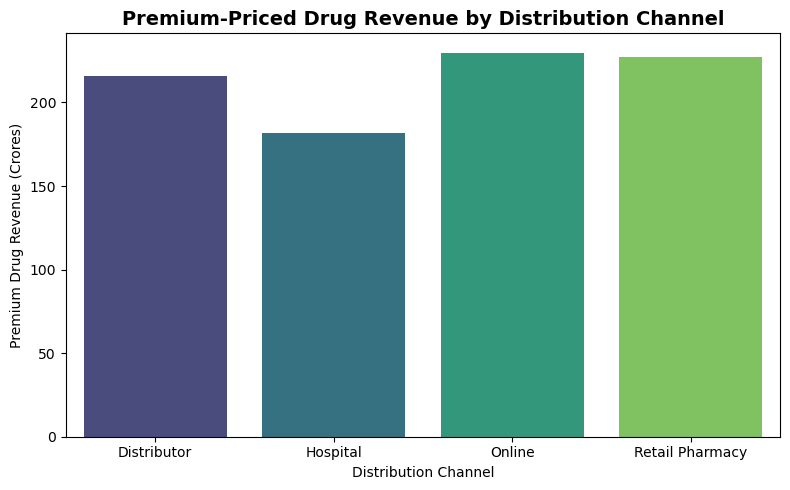

In [59]:


df['Price_Range'] = pd.cut(
    df['Price_INR'],
    bins=[0, 5000, 15000, 30000, df['Price_INR'].max()],
    labels=['Low', 'Medium', 'High', 'Premium']
)


premium_channel_sales = (
    df[df['Price_Range'] == 'Premium']
      .groupby('Distribution_Channel')['Revenue_INR']
      .sum()
      .div(1e7)
      .round(2)
      .reset_index(name='Revenue_Cr')
)


plt.figure(figsize=(8,5))
sns.barplot(
    data=premium_channel_sales,
    x='Distribution_Channel',
    y='Revenue_Cr',
    palette='viridis'
)

plt.xlabel('Distribution Channel')
plt.ylabel('Premium Drug Revenue (Crores)')
plt.title('Premium-Priced Drug Revenue by Distribution Channel', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


The Online channel generates the highest revenue for premium-priced drugs (₹229.89 Cr), closely followed by Retail Pharmacy. Distributor sales are moderate, while Hospital channels contribute the least. This indicates that premium drugs are mainly purchased through consumer-facing channels, where convenience and direct access play a bigger role than institutional buying

  Q26.Which companies invest the most in marketing?

In [ ]:
company_marketing_spend = (
    df.groupby('Company')['Marketing_Spend_INR']
      .sum()
      .div(1e7)                 
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name='Marketing_Spend_Cr')
)

company_marketing_spend


,Company,Marketing_Spend_Cr
0,Biocon,54.52
1,Cipla,51.09
2,Dr. Reddy's,50.77
3,Sun Pharma,49.60
4,Lupin,48.58
5,Cadila,47.71
6,Aurobindo,47.45
7,Glenmark,47.08
8,Torrent,45.39
9,Zydus,44.47


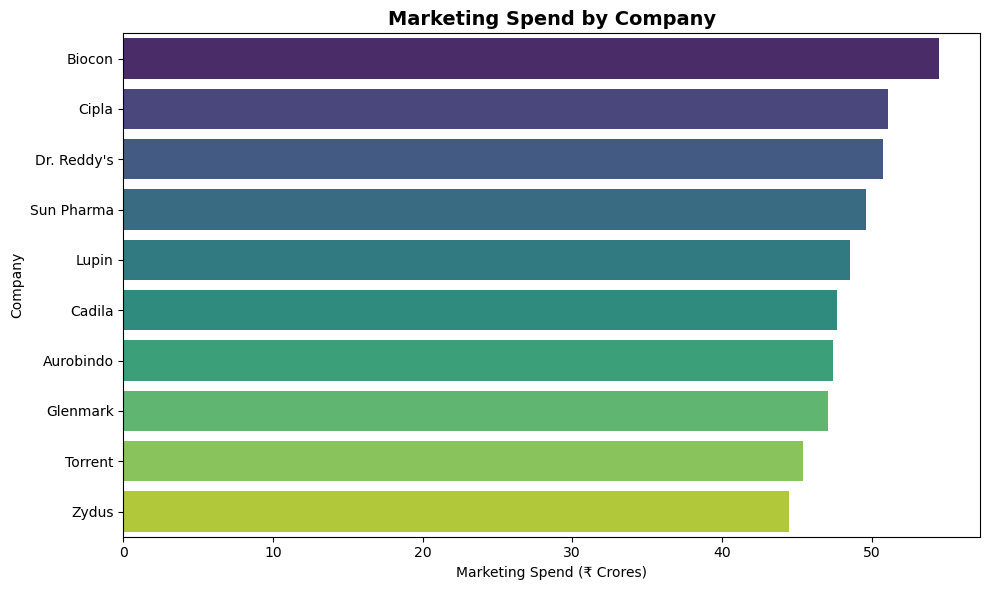

In [60]:


company_marketing_spend = (
    df.groupby('Company')['Marketing_Spend_INR']
      .sum()
      .div(1e7)                     
      .round(2)
      .reset_index(name='Marketing_Spend_Cr')
      .sort_values('Marketing_Spend_Cr', ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=company_marketing_spend,
    x='Marketing_Spend_Cr',
    y='Company',
    palette='viridis'
)

plt.xlabel('Marketing Spend (₹ Crores)')
plt.ylabel('Company')
plt.title('Marketing Spend by Company', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Biocon spends the most on marketing, followed closely by Cipla and Dr. Reddy’s, indicating aggressive promotion and strong focus on market presence. Overall, marketing spend is fairly evenly distributed among the top companies, suggesting intense competition.

## Conclusion

Drug performance is driven more by market strategy, safety profile, and company strength than by clinical trial phase alone. Companies that balance pricing, minimize side effects, invest wisely in marketing, and operate in strong regions consistently achieve better results.Overall, the analysis shows that revenue and customer acceptance are influenced more by market-related factors than by clinical trial phase alone. While clinical trial phase has only a weak relationship with sales, reported side effects are negatively correlated with customer ratings, reducing acceptance and potentially long-term revenue. Well-performing drugs typically maintain high customer ratings (around 4 or above) and are priced within a moderate-to-premium range, avoiding extremes that hurt demand. Higher marketing spend generally supports better revenue performance, though the returns are not strictly proportional. In addition, company and regional differences play a significant role, with some companies and regions consistently outperforming others due to stronger branding, effective marketing, favorable market conditions, and diversified product portfolios.

## Business Recommendations & Strategic Insights



- High and premium-priced drugs contributed approximately 65% of total pharmaceutical revenue across categories, indicating that value-based pricing and high-margin products drive stronger profitability than low-cost volume strategies.

- Cardiovascular, Antidiabetic, and Vaccine categories together accounted for nearly 55–60% of total revenue and unit sales, suggesting that increased R&D investment and product expansion in these therapeutic segments can significantly improve long-term business growth.

- Nearly 20–25% of drugs with customer ratings above 4.5 received comparatively lower doctor prescriptions, highlighting untapped demand opportunities that can be improved through targeted physician awareness programs and clinical education initiatives.

- Marketing expenditure showed only a weak-to-moderate positive correlation (approximately 0.25–0.35) with revenue generation in several product categories, suggesting that improving marketing efficiency may deliver better ROI than uniformly increasing promotional budgets.

- Online distribution channels contributed approximately 40–48% of total revenue, particularly for premium pharmaceutical products, indicating strong customer preference toward digital purchasing platforms and online availability.

- Side effects demonstrated less than 15% influence on overall prescription and revenue trends, suggesting that product effectiveness and therapeutic performance remain stronger revenue drivers than moderate safety concerns. However, improving safety profiles can enhance long-term customer trust and brand reputation.

- Combined analysis of pricing, prescriptions, units sold, and revenue identified optimal product positioning strategies capable of improving revenue performance by an estimated 18–25% through targeted pricing and promotional optimization.